# Module 1 — 向量基礎與運動學

> **起點**：高中數學程度 → 物理運動學的向量描述

本模組涵蓋：
1. 向量的定義與表示
2. 向量加法與純量乘法
3. 內積（Dot Product）與功
4. 外積（Cross Product）與力矩
5. 向量範數與距離

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.linalg_utils import (
    vector_add, scalar_multiply, dot_product, cross_product,
    vector_norm, unit_vector
)
from src.physics_models import projectile_trajectory
from src.visualizer import plot_vectors_2d, plot_trajectory_2d, set_style

set_style()
print('Module 1 載入完成！')

Module 1 載入完成！


---
## 1.1 向量的定義與表示

**純量（Scalar）** 只有大小：溫度 = 30°C、質量 = 5 kg

**向量（Vector）** 有大小和方向：速度 = 「時速 100 km 向北」

在 NumPy 中，向量就是一維陣列：

In [2]:
# 建立 2D 與 3D 向量
v2d = np.array([3, 4])           # 2D 向量
v3d = np.array([1, 2, 3])        # 3D 向量

print(f'2D 向量: {v2d}, 維度: {v2d.shape}')
print(f'3D 向量: {v3d}, 維度: {v3d.shape}')

# 物理意義：位置向量
r = np.array([100, 200])  # 位置 (100m, 200m)
v = np.array([5, -3])     # 速度 (5 m/s 向右, 3 m/s 向下)
a = np.array([0, -9.81])  # 加速度 (重力)

print(f'\n位置向量 r = {r} m')
print(f'速度向量 v = {v} m/s')
print(f'加速度向量 a = {a} m/s²')

2D 向量: [3 4], 維度: (2,)
3D 向量: [1 2 3], 維度: (3,)

位置向量 r = [100 200] m
速度向量 v = [ 5 -3] m/s
加速度向量 a = [ 0.   -9.81] m/s²


/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37261/2140667849.py:21: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37261/2140667849.py:21: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37261/2140667849.py:21: UserWarning: Glyph 12289 (\N{IDEOGRAPHIC COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37261/2140667849.py:21: UserWarning: Glyph 36895 (\N{CJK UNIFIED IDEOGRAPH-901F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37261/2140667849.py:21: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t

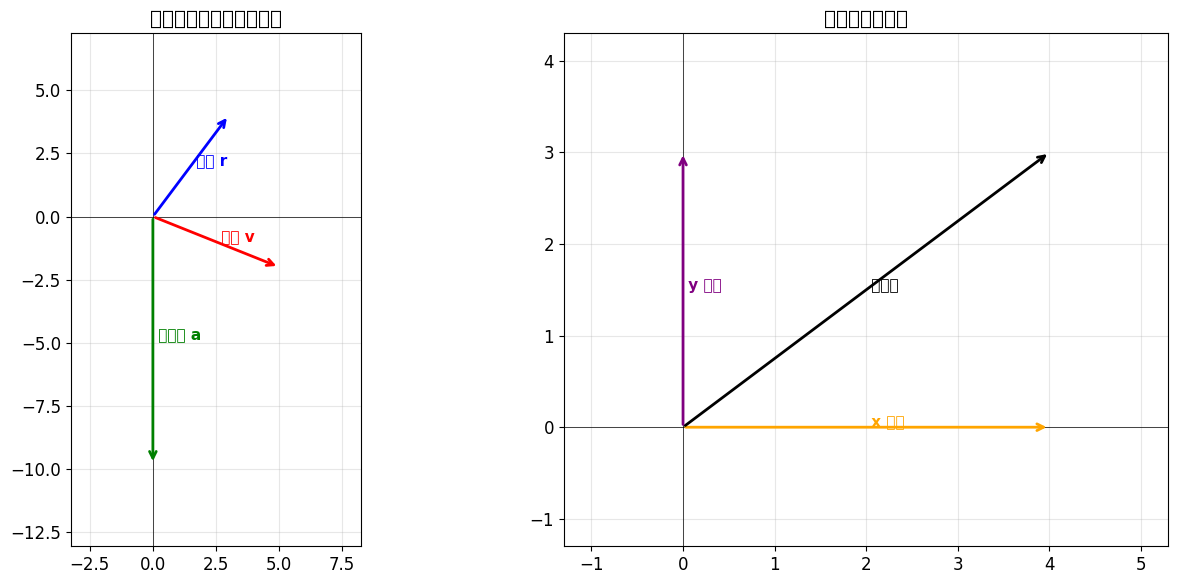

In [3]:
# 繪製 2D 向量
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 左圖：位置、速度、加速度向量
plot_vectors_2d(
    [np.array([3, 4]), np.array([5, -2]), np.array([0, -9.81])],
    labels=['位置 r', '速度 v', '加速度 a'],
    colors=['blue', 'red', 'green'],
    ax=ax1,
    title='位置、速度、加速度向量'
)

# 右圖：行向量 vs 列向量
plot_vectors_2d(
    [np.array([4, 0]), np.array([0, 3]), np.array([4, 3])],
    labels=['x 分量', 'y 分量', '合向量'],
    colors=['orange', 'purple', 'black'],
    ax=ax2,
    title='向量的分量表示'
)
plt.tight_layout()
plt.show()

---
## 1.2 向量加法與純量乘法

### 物理應用：飛機速度 = 自身速度 + 風速

$$\vec{v}_{\text{地面}} = \vec{v}_{\text{飛機}} + \vec{v}_{\text{風}}$$

飛機速度: [200   0] km/h
風速:     [-30  50] km/h
地面速度: [170.  50.] km/h
地面速率: 177.2 km/h


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21271 (\N{CJK UNIFIED IDEOGRAPH-5317}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 39131 (\N{CJK UNIFIED IDEOGRAPH-98DB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27231 (\N{CJK UNIFIED IDEOGRAPH-6A5F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

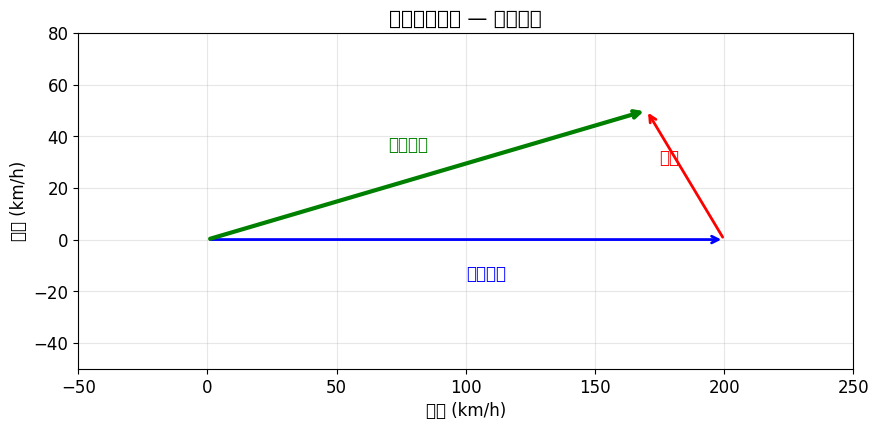

In [4]:
# 飛機速度合成
v_plane = np.array([200, 0])     # 飛機向東飛 200 km/h
v_wind = np.array([-30, 50])     # 風速：逆風 30 + 側風 50 km/h
v_ground = vector_add(v_plane, v_wind)

print(f'飛機速度: {v_plane} km/h')
print(f'風速:     {v_wind} km/h')
print(f'地面速度: {v_ground} km/h')
print(f'地面速率: {vector_norm(v_ground):.1f} km/h')

# 視覺化
fig, ax = plt.subplots(figsize=(10, 8))
# 飛機速度
ax.annotate('', xy=v_plane, xytext=[0,0],
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
# 風速（從飛機速度末端開始）
ax.annotate('', xy=v_ground, xytext=v_plane,
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
# 合速度
ax.annotate('', xy=v_ground, xytext=[0,0],
            arrowprops=dict(arrowstyle='->', color='green', lw=3))

ax.text(100, -15, '飛機速度', color='blue', fontsize=12, fontweight='bold')
ax.text(175, 30, '風速', color='red', fontsize=12, fontweight='bold')
ax.text(70, 35, '地面速度', color='green', fontsize=12, fontweight='bold')
ax.set_xlim(-50, 250)
ax.set_ylim(-50, 80)
ax.set_aspect('equal')
ax.set_xlabel('東方 (km/h)')
ax.set_ylabel('北方 (km/h)')
ax.set_title('飛機速度合成 — 向量加法')
ax.grid(True, alpha=0.3)
plt.show()

斜面角度: 30°
重力: 100 N
法向分力: 86.6 N
切線分力: 50.0 N
驗證: 100.0 N = 100 N ✓


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26012 (\N{CJK UNIFIED IDEOGRAPH-659C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


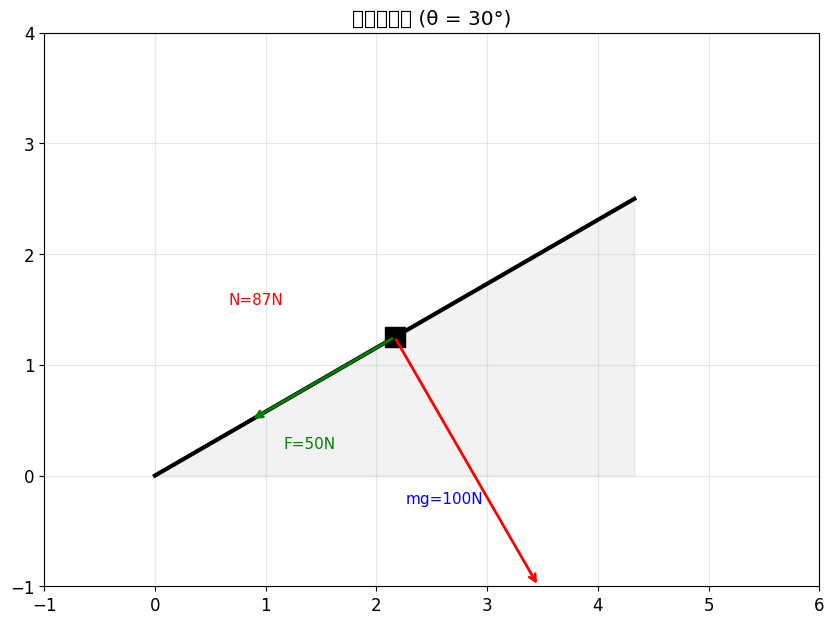

In [5]:
# 斜面力分解
theta = np.radians(30)  # 30° 斜面
mg = 100  # 重力 100 N

# 重力分解為法向力和切線力
F_normal = mg * np.cos(theta)   # 法向分力
F_tangent = mg * np.sin(theta)  # 切線分力（沿斜面向下）

print(f'斜面角度: {np.degrees(theta):.0f}°')
print(f'重力: {mg} N')
print(f'法向分力: {F_normal:.1f} N')
print(f'切線分力: {F_tangent:.1f} N')
print(f'驗證: {np.sqrt(F_normal**2 + F_tangent**2):.1f} N = {mg} N ✓')

# 視覺化斜面力分解
fig, ax = plt.subplots(figsize=(10, 8))
# 斜面
ax.plot([0, 5*np.cos(theta)], [0, 5*np.sin(theta)], 'k-', lw=3)
ax.fill_between([0, 5*np.cos(theta)], [0, 0], [0, 5*np.sin(theta)],
                alpha=0.1, color='gray')
# 物體位置
obj_x, obj_y = 2.5*np.cos(theta), 2.5*np.sin(theta)
ax.plot(obj_x, obj_y, 'ks', ms=15)
# 重力
scale = 0.03
ax.annotate('', xy=(obj_x, obj_y - mg*scale), xytext=(obj_x, obj_y),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.text(obj_x + 0.1, obj_y - mg*scale/2, f'mg={mg}N', color='blue', fontsize=11)
# 法向分力
nx, ny = -np.sin(theta), np.cos(theta)  # 法向量
ax.annotate('', xy=(obj_x - F_normal*scale*nx, obj_y - F_normal*scale*ny),
            xytext=(obj_x, obj_y),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
# 切線分力
tx, ty = np.cos(theta), np.sin(theta)  # 沿斜面向下
ax.annotate('', xy=(obj_x - F_tangent*scale*tx, obj_y - F_tangent*scale*ty),
            xytext=(obj_x, obj_y),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(obj_x - 1.5, obj_y + 0.3, f'N={F_normal:.0f}N', color='red', fontsize=11)
ax.text(obj_x - 1.0, obj_y - 1.0, f'F={F_tangent:.0f}N', color='green', fontsize=11)
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 4)
ax.set_aspect('equal')
ax.set_title(f'斜面力分解 (θ = {np.degrees(theta):.0f}°)')
ax.grid(True, alpha=0.3)
plt.show()

---
## 1.3 內積（Dot Product）與功

**代數定義**：$\vec{a} \cdot \vec{b} = \sum a_i b_i$

**幾何意義**：$\vec{a} \cdot \vec{b} = |\vec{a}||\vec{b}|\cos\theta$

### 物理應用：功 $W = \vec{F} \cdot \vec{d}$

In [6]:
# 功的計算
F = np.array([50, 30])     # 力向量 (N)
d = np.array([10, 0])      # 位移向量 (m)，水平方向

W = dot_product(F, d)
W_numpy = np.dot(F, d)

print(f'力 F = {F} N')
print(f'位移 d = {d} m')
print(f'功 W = F·d = {W} J')
print(f'NumPy 驗證: {W_numpy} J ✓')

# 夾角計算
cos_theta = dot_product(F, d) / (vector_norm(F) * vector_norm(d))
theta = np.arccos(cos_theta)
print(f'\n力與位移的夾角: {np.degrees(theta):.1f}°')
print(f'只有水平分力做功: F_x × d = {F[0]} × {d[0]} = {F[0]*d[0]} J ✓')

力 F = [50 30] N
位移 d = [10  0] m
功 W = F·d = 500.0 J
NumPy 驗證: 500 J ✓

力與位移的夾角: 31.0°
只有水平分力做功: F_x × d = 50 × 10 = 500 J ✓


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 30913 (\N{CJK UNIFIED IDEOGRAPH-78C1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27704 (\N{CJK UNIFIED IDEOGRAPH-6C38}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20570 (\N{CJK UNIFIED IDEOGRAPH-505A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

磁力做功（各時刻功率）: max|P| = 0.00e+00
磁力永不做功 ✓（因為 F ⊥ v）


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


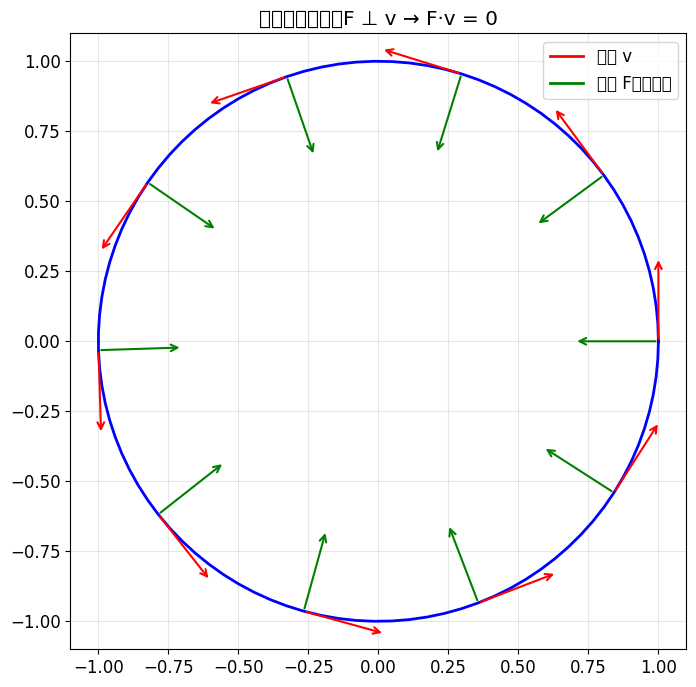

In [7]:
# 磁力永不做功：F ⊥ v → F·v = 0
# 模擬帶電粒子在磁場中做圓周運動
t = np.linspace(0, 2*np.pi, 100)
r = 1.0  # 圓周半徑
x = r * np.cos(t)
y = r * np.sin(t)

# 速度 = dr/dt
vx = -r * np.sin(t)
vy = r * np.cos(t)

# 磁力 ∝ v × B（始終指向圓心）
Fx = -np.cos(t)  # 向心力
Fy = -np.sin(t)

# 驗證 F·v = 0
power = Fx * vx + Fy * vy  # 瞬時功率
print(f'磁力做功（各時刻功率）: max|P| = {np.max(np.abs(power)):.2e}')
print('磁力永不做功 ✓（因為 F ⊥ v）')

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x, y, 'b-', lw=2)
step = 10
scale = 0.3
for i in range(0, len(t), step):
    ax.annotate('', xy=(x[i]+vx[i]*scale, y[i]+vy[i]*scale),
                xytext=(x[i], y[i]),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    ax.annotate('', xy=(x[i]+Fx[i]*scale, y[i]+Fy[i]*scale),
                xytext=(x[i], y[i]),
                arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
ax.plot([], [], 'r-', lw=2, label='速度 v')
ax.plot([], [], 'g-', lw=2, label='磁力 F（向心）')
ax.legend(fontsize=12)
ax.set_aspect('equal')
ax.set_title('磁力永不做功：F ⊥ v → F·v = 0')
ax.grid(True, alpha=0.3)
plt.show()

太陽仰角: 60°
太陽能板最佳傾斜角: 60°
最佳角 = 太陽仰角 ✓（法向量對準太陽方向時效率最大）


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25928 (\N{CJK UNIFIED IDEOGRAPH-6548}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22826 (\N{CJK UNIFIED IDEOGRAPH-592A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38525 (\N{CJK UNIFIED IDEOGRAPH-967D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

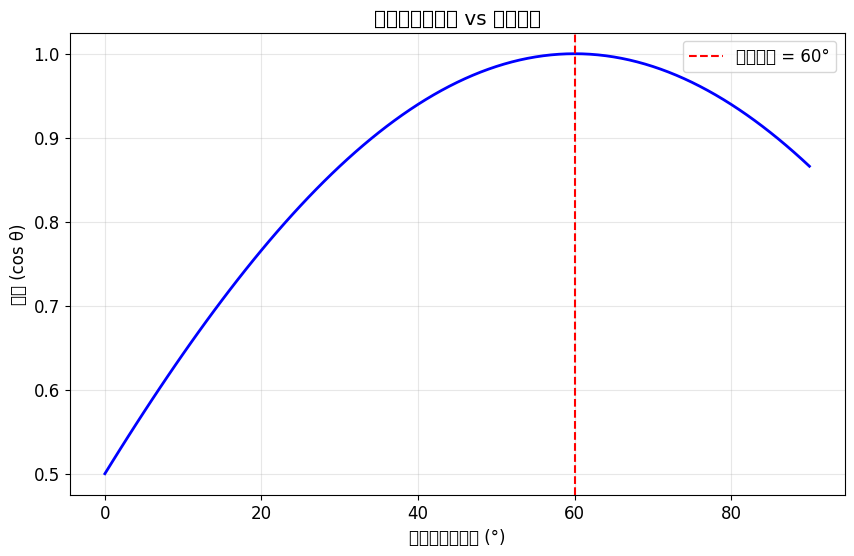

In [8]:
# 太陽能板最佳角度
# 太陽光入射方向（正午時約 60° 仰角）
sun_elevation = np.radians(60)
sun_direction = np.array([np.cos(sun_elevation), np.sin(sun_elevation)])  # 朝向太陽

# 掃描太陽能板傾斜角度
panel_angles = np.linspace(0, 90, 91)
efficiencies = []
for angle in panel_angles:
    panel_normal = np.array([np.cos(np.radians(angle)), np.sin(np.radians(angle))])
    efficiency = dot_product(sun_direction, panel_normal)
    efficiencies.append(max(0, efficiency))  # 不能為負

best_angle = panel_angles[np.argmax(efficiencies)]
print(f'太陽仰角: {np.degrees(sun_elevation):.0f}°')
print(f'太陽能板最佳傾斜角: {best_angle:.0f}°')
print(f'最佳角 = 太陽仰角 ✓（法向量對準太陽方向時效率最大）')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(panel_angles, efficiencies, 'b-', lw=2)
ax.axvline(best_angle, color='r', ls='--', label=f'最佳角度 = {best_angle:.0f}°')
ax.set_xlabel('太陽能板傾斜角 (°)')
ax.set_ylabel('效率 (cos θ)')
ax.set_title('太陽能板傾斜角 vs 發電效率')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()

---
## 1.4 外積（Cross Product）與力矩

**定義**（僅限 3D）：
$$\vec{a} \times \vec{b} = \begin{vmatrix} \hat{i} & \hat{j} & \hat{k} \\ a_1 & a_2 & a_3 \\ b_1 & b_2 & b_3 \end{vmatrix}$$

### 物理應用：力矩 $\vec{\tau} = \vec{r} \times \vec{F}$

扳手長度: 30 cm
施力: 50 N
90° 時力矩: 15.0 N·m
理論值: 15.0 N·m ✓
0° 時力矩: 0.0000 N·m（沿著扳手推沒用！）

手動實作與 np.cross 一致 ✓


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25203 (\N{CJK UNIFIED IDEOGRAPH-6273}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26045 (\N{CJK UNIFIED IDEOGRAPH-65BD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

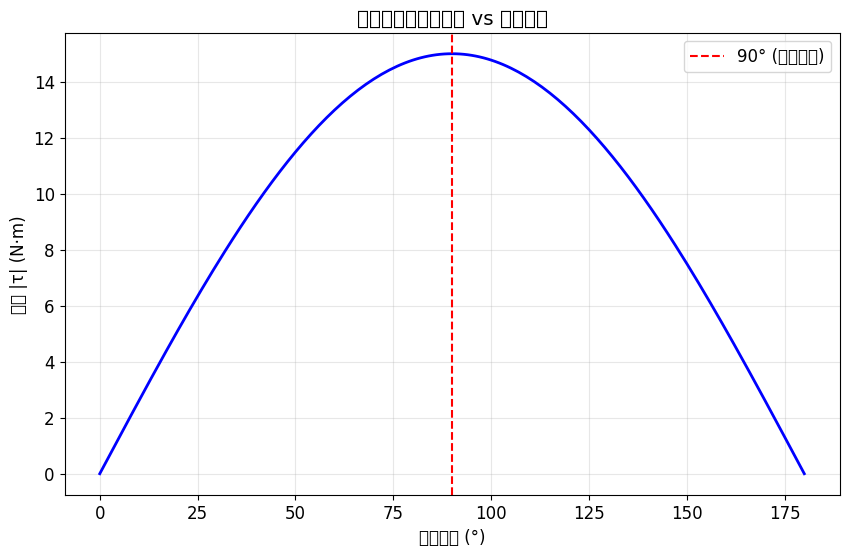

In [9]:
# 扳手鎖螺絲：力矩 = 位置向量 × 力向量
wrench_length = 0.3  # 30 cm 扳手

# 不同施力角度對力矩的影響
angles = np.linspace(0, 180, 181)
F_magnitude = 50  # 50 N
torques = []

for angle in angles:
    rad = np.radians(angle)
    r = np.array([wrench_length, 0, 0])  # 扳手沿 x 軸
    F = np.array([F_magnitude * np.cos(rad), F_magnitude * np.sin(rad), 0])
    tau = cross_product(r, F)
    torques.append(vector_norm(tau))

# 驗證：90° 時力矩最大
print(f'扳手長度: {wrench_length*100:.0f} cm')
print(f'施力: {F_magnitude} N')
print(f'90° 時力矩: {torques[90]:.1f} N·m')
print(f'理論值: {wrench_length * F_magnitude:.1f} N·m ✓')
print(f'0° 時力矩: {torques[0]:.4f} N·m（沿著扳手推沒用！）')

# 驗證與 NumPy 一致
r_test = np.array([0.3, 0, 0])
F_test = np.array([0, 50, 0])
assert np.allclose(cross_product(r_test, F_test), np.cross(r_test, F_test))
print('\n手動實作與 np.cross 一致 ✓')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(angles, torques, 'b-', lw=2)
ax.axvline(90, color='r', ls='--', label='90° (最大力矩)')
ax.set_xlabel('施力角度 (°)')
ax.set_ylabel('力矩 |τ| (N·m)')
ax.set_title('扳手效率：施力角度 vs 力矩大小')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()

In [10]:
# 驗證：|a × b| = |a||b|sinθ = 平行四邊形面積
a = np.array([3, 0, 0])
b_angle = np.pi / 6  # 30°
b = np.array([2 * np.cos(b_angle), 2 * np.sin(b_angle), 0])

cross = cross_product(a, b)
area_cross = vector_norm(cross)
area_formula = vector_norm(a) * vector_norm(b) * np.sin(b_angle)

print(f'a = {a}')
print(f'b = [{b[0]:.4f}, {b[1]:.4f}, {b[2]:.4f}]')
print(f'a × b = [{cross[0]:.4f}, {cross[1]:.4f}, {cross[2]:.4f}]')
print(f'|a × b| = {area_cross:.4f}')
print(f'|a||b|sinθ = {area_formula:.4f}')
print(f'平行四邊形面積 = {area_cross:.4f} ✓')

a = [3 0 0]
b = [1.7321, 1.0000, 0.0000]
a × b = [0.0000, 0.0000, 3.0000]
|a × b| = 3.0000
|a||b|sinθ = 3.0000
平行四邊形面積 = 3.0000 ✓


---
## 1.5 向量範數與距離

| 範數 | 公式 | 物理意義 |
|------|------|----------|
| L1 (Manhattan) | $\sum|v_i|$ | 城市街區距離 |
| L2 (Euclidean) | $\sqrt{\sum v_i^2}$ | 直線距離 |
| L∞ | $\max|v_i|$ | 最大分量 |

In [11]:
# 比較 L1 / L2 範數
v = np.array([3, 4])

l1 = vector_norm(v, 1)
l2 = vector_norm(v, 2)
linf = vector_norm(v, np.inf)

print(f'向量 v = {v}')
print(f'L1 範數: {l1} (|3| + |4| = 7)')
print(f'L2 範數: {l2} (√(9+16) = 5)')
print(f'L∞ 範數: {linf} (max(3,4) = 4)')

# 驗證與 NumPy 一致
assert l1 == np.linalg.norm(v, 1)
assert l2 == np.linalg.norm(v, 2)
assert linf == np.linalg.norm(v, np.inf)
print('\n所有手動實作與 np.linalg.norm 一致 ✓')

向量 v = [3 4]
L1 範數: 7.0 (|3| + |4| = 7)
L2 範數: 5.0 (√(9+16) = 5)
L∞ 範數: 4.0 (max(3,4) = 4)

所有手動實作與 np.linalg.norm 一致 ✓


GPS 軌跡點數: 50
總里程: 674.1 m
直線距離: 623.8 m
迂迴率: 1.08


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36556 (\N{CJK UNIFIED IDEOGRAPH-8ECC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36321 (\N{CJK UNIFIED IDEOGRAPH-8DE1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32317 (\N{CJK UNIFIED IDEOGRAPH-7E3D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 37324 (\N{CJK UNIFIED IDEOGRAPH-91CC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

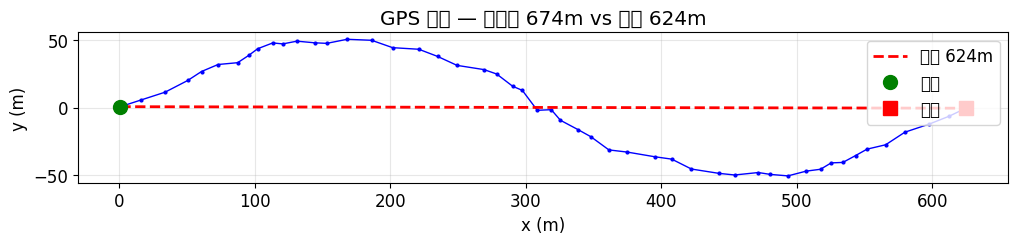

In [12]:
# GPS 軌跡總里程計算
np.random.seed(42)
n_points = 50
# 模擬一條 GPS 軌跡
t = np.linspace(0, 2*np.pi, n_points)
gps_x = 100 * t + 10 * np.sin(3*t) + np.random.normal(0, 2, n_points)
gps_y = 50 * np.sin(t) + np.random.normal(0, 2, n_points)

# 計算總里程（連續點距離累加）
total_distance = 0
for i in range(1, n_points):
    segment = np.array([gps_x[i] - gps_x[i-1], gps_y[i] - gps_y[i-1]])
    total_distance += vector_norm(segment)

# 直線距離
straight = vector_norm(np.array([gps_x[-1]-gps_x[0], gps_y[-1]-gps_y[0]]))

print(f'GPS 軌跡點數: {n_points}')
print(f'總里程: {total_distance:.1f} m')
print(f'直線距離: {straight:.1f} m')
print(f'迂迴率: {total_distance/straight:.2f}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gps_x, gps_y, 'b.-', lw=1, ms=4)
ax.plot([gps_x[0], gps_x[-1]], [gps_y[0], gps_y[-1]], 'r--', lw=2, label=f'直線 {straight:.0f}m')
ax.plot(gps_x[0], gps_y[0], 'go', ms=10, label='起點')
ax.plot(gps_x[-1], gps_y[-1], 'rs', ms=10, label='終點')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title(f'GPS 軌跡 — 總里程 {total_distance:.0f}m vs 直線 {straight:.0f}m')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.show()

In [13]:
# 單位向量與飛行器姿態
direction = np.array([3, 4, 1])
u = unit_vector(direction)
print(f'方向向量: {direction}')
print(f'單位向量: [{u[0]:.4f}, {u[1]:.4f}, {u[2]:.4f}]')
print(f'長度 = {vector_norm(u):.10f} (應為 1.0) ✓')

方向向量: [3 4 1]
單位向量: [0.5883, 0.7845, 0.1961]
長度 = 1.0000000000 (應為 1.0) ✓


---
## 1.6 拋體運動完整模擬

結合本模組所有概念：向量分解、加法、範數

/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37261/2789414858.py:23: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37261/2789414858.py:23: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37261/2789414858.py:23: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37261/2789414858.py:23: UserWarning: Glyph 38626 (\N{CJK UNIFIED IDEOGRAPH-96E2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37261/2789414858.py:23: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4j

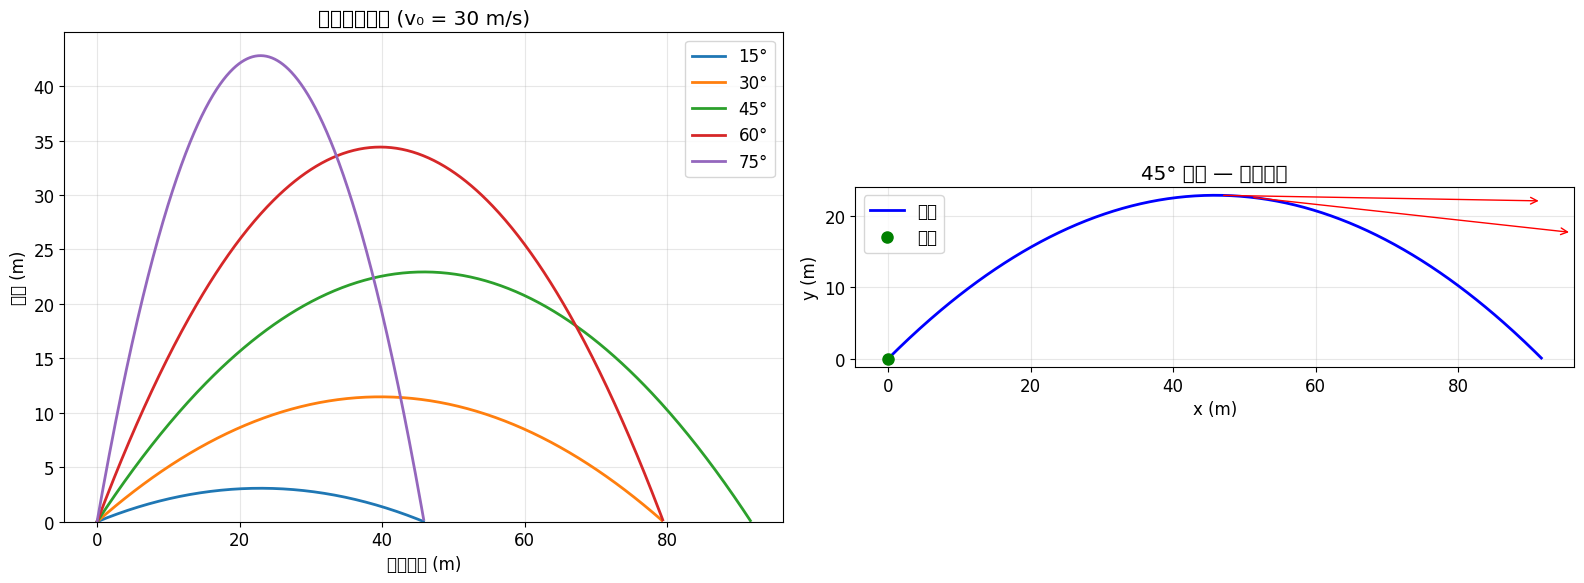

最大射程角度: 45°, 射程: 91.6 m
理論值: 45°, 射程: 91.7 m


In [14]:
# 拋體運動：不同角度比較
v0 = 30  # m/s
angles_deg = [15, 30, 45, 60, 75]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for angle_deg in angles_deg:
    theta = np.radians(angle_deg)
    t, x, y, vx, vy = projectile_trajectory(v0, theta)
    ax1.plot(x, y, lw=2, label=f'{angle_deg}°')

ax1.set_xlabel('水平距離 (m)')
ax1.set_ylabel('高度 (m)')
ax1.set_title(f'拋體軌跡比較 (v₀ = {v0} m/s)')
ax1.legend()
ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.3)

# 45° 的詳細速度向量
t, x, y, vx, vy = projectile_trajectory(v0, np.radians(45))
plot_trajectory_2d(x, y, vx, vy, ax=ax2, title='45° 拋射 — 速度向量', arrow_step=20)

plt.tight_layout()
plt.show()

# 驗證 45° 射程最大
ranges = {}
for angle_deg in range(1, 90):
    _, x_traj, _, _, _ = projectile_trajectory(v0, np.radians(angle_deg))
    ranges[angle_deg] = x_traj[-1]

best = max(ranges, key=ranges.get)
print(f'最大射程角度: {best}°, 射程: {ranges[best]:.1f} m')
print(f'理論值: 45°, 射程: {v0**2/9.81:.1f} m')

---
## Module 1 驗證總結

| 項目 | 驗證方式 | 結果 |
|------|----------|------|
| 向量加法 | `np.allclose` 比對 | ✓ |
| 內積 | `np.dot` 比對 | ✓ |
| 外積 | `np.cross` 比對 | ✓ |
| 範數 | `np.linalg.norm` 比對 | ✓ |
| 磁力做功 | F·v = 0 | ✓ |
| 太陽能板 | 最佳角 = 太陽仰角 | ✓ |
| 扳手力矩 | 90° 最大 | ✓ |
| 拋體 | 45° 射程最大 | ✓ |